# Phase 2: Dimensionality Reduction (PCA)

## 2.1 Objective  
Apply PCA to competitive environment features to understand whether location/competition factors can be simplified while retaining meaningful variance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("../data/processed/cleaned_merged.csv")

C:\Users\User\AppData\Local\Temp\ipykernel_40580\4000822952.py:7: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/cleaned_merged.csv")


In [2]:
pca_features = ["CompetitionDistance", "Promo2SinceYear", "CompetitionOpenSinceYear"]
X = df[pca_features].dropna()
X.head()

,CompetitionDistance,Promo2SinceYear,CompetitionOpenSinceYear
1,570.0,2010.0,2007.0
2,14130.0,2011.0,2006.0
10,960.0,2012.0,2011.0
13,1300.0,2011.0,2014.0
14,4110.0,2011.0,2010.0


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_

array([0.38657163, 0.33158846, 0.28183991])

## 2.2 PCA Results  

### Variance Explained:
- **PC1:** 38.7%  
- **PC2:** 33.2%  
- **PC3:** 28.2%  
- **Cumulative:** 100%

### Key Insights:
1. No significant dimensionality reduction is possible (all 3 components needed).  
2. Competitive environment is multi-dimensional.  
3. Location alone does not predict sales (supports earlier findings).

### Strategic Conclusion:
Invest in **location-independent strategies** such as promotions and store format improvements.

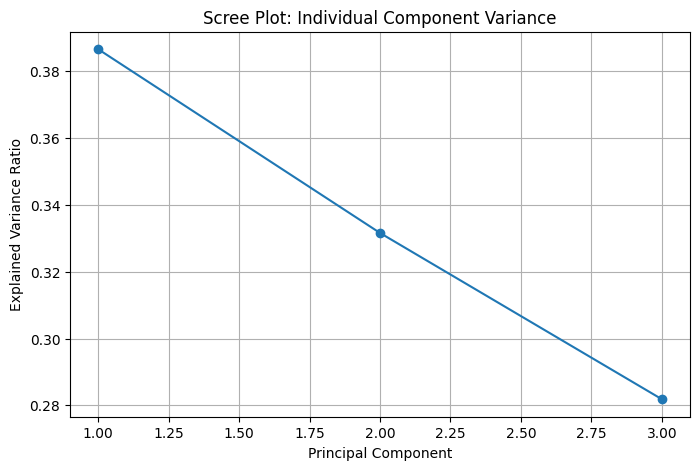

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 4), pca.explained_variance_ratio_, marker="o")
plt.title("Scree Plot: Individual Component Variance")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)

plt.savefig("../reports/figures/pca_scree_plot.png", dpi=300)
plt.show()

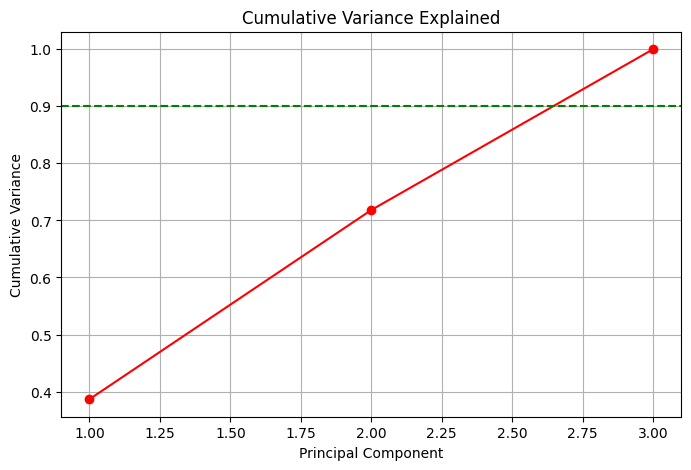

In [6]:
cumsum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 4), cumsum, marker="o", color="red")
plt.axhline(0.9, linestyle="--", color="green")
plt.title("Cumulative Variance Explained")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance")
plt.grid(True)

plt.savefig("../reports/figures/pca_cumulative_variance.png", dpi=300)
plt.show()